In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# read file into df
df = pd.read_parquet('compiled_data.parquet')

In [2]:
# print shape and info
print(f'Shape: {df.shape}\n')
print(df.info())

Shape: (5068, 97)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5068 entries, 0 to 5067
Data columns (total 97 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SEQN                                5068 non-null   float64
 1   gender                              5068 non-null   float64
 2   age                                 5068 non-null   float64
 3   pregnancy_status                    962 non-null    float64
 4   reported_race                       5068 non-null   float64
 5   2_year_interview_weight             5068 non-null   float64
 6   2_year_mec_exam_weight              5068 non-null   float64
 7   heart_rate                          0 non-null      float64
 8   diastolic_bp_1                      4564 non-null   float64
 9   diastolic_bp_2                      4780 non-null   float64
 10  diastolic_bp_3                      4770 non-null   float64
 11  mil                     

In [3]:
# print top 5 rows of each column
for col in df.columns:
    print(col)
    print(df[col].head())

SEQN
0    93705.0
1    93706.0
2    93708.0
3    93711.0
4    93712.0
Name: SEQN, dtype: float64
gender
0    2.0
1    1.0
2    2.0
3    1.0
4    1.0
Name: gender, dtype: float64
age
0    66.0
1    18.0
2    66.0
3    56.0
4    18.0
Name: age, dtype: float64
pregnancy_status
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: pregnancy_status, dtype: float64
reported_race
0    4.0
1    6.0
2    6.0
3    6.0
4    1.0
Name: reported_race, dtype: float64
2_year_interview_weight
0     8614.571172
1     8548.632619
2    13329.450589
3    11178.260106
4    29040.496558
Name: 2_year_interview_weight, dtype: float64
2_year_mec_exam_weight
0     8338.419786
1     8723.439814
2    14372.488765
3    12390.919724
4    30336.654325
Name: 2_year_mec_exam_weight, dtype: float64
heart_rate
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: heart_rate, dtype: float64
diastolic_bp_1
0     NaN
1    74.0
2     NaN
3    68.0
4    68.0
Name: diastolic_bp_1, dtype: float64
diastolic_bp_2
0     NaN
1    70.0
2    78.0
3 

In [4]:
#print number of unique values for outcome variables
print(f'{df['depression_category'].value_counts()}\n')
print(df['depression_binary'].value_counts())


depression_category
Minimal or no depression        3772
Mild depression                  837
Moderate depression              292
Moderately severe depression     124
Severe depression                 43
Name: count, dtype: int64

depression_binary
False    4609
True      459
Name: count, dtype: int64


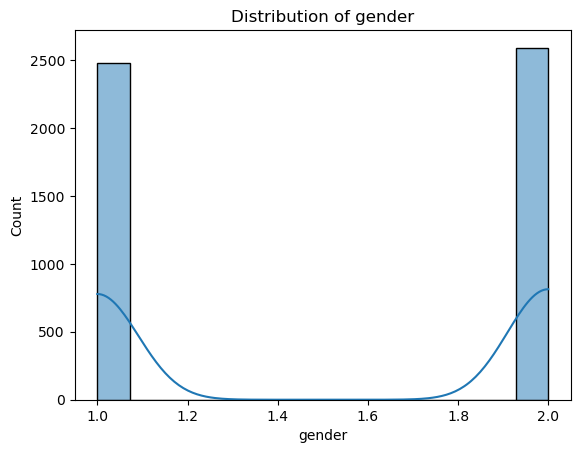

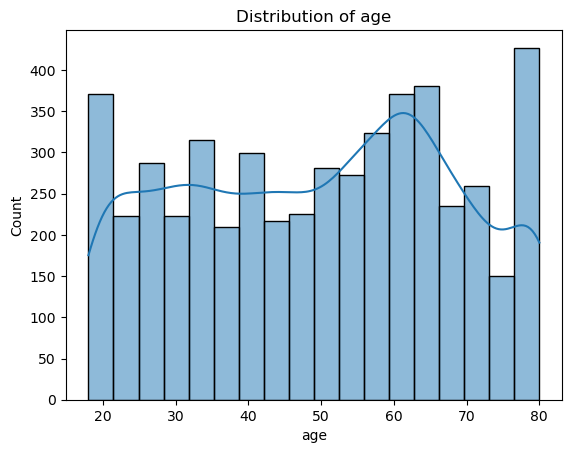

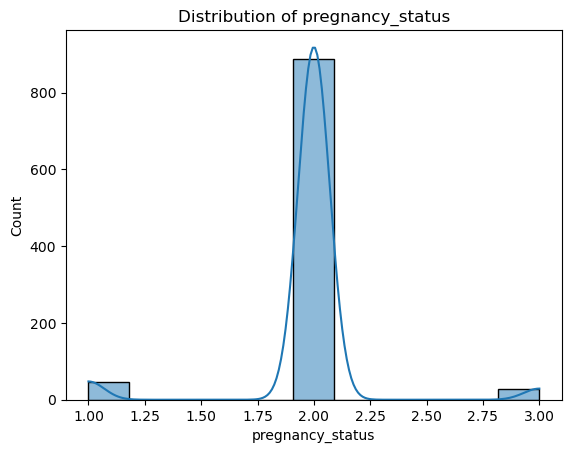

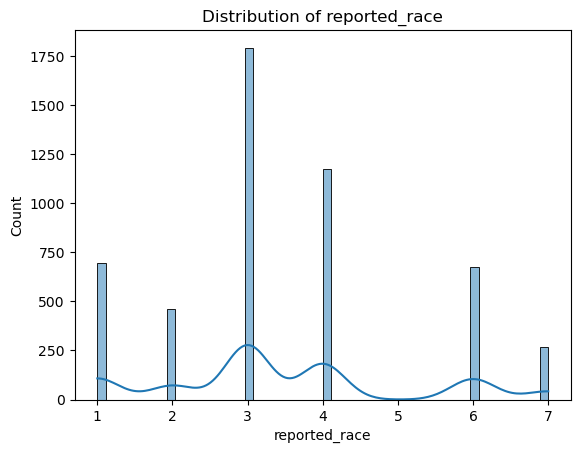

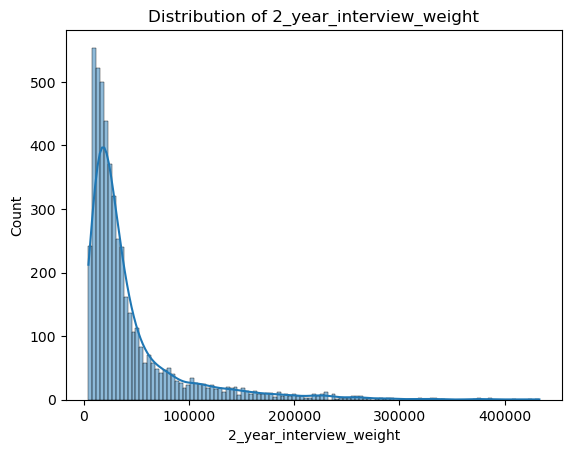

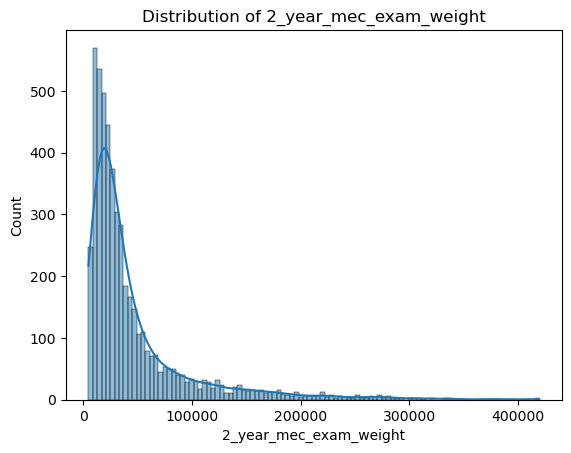

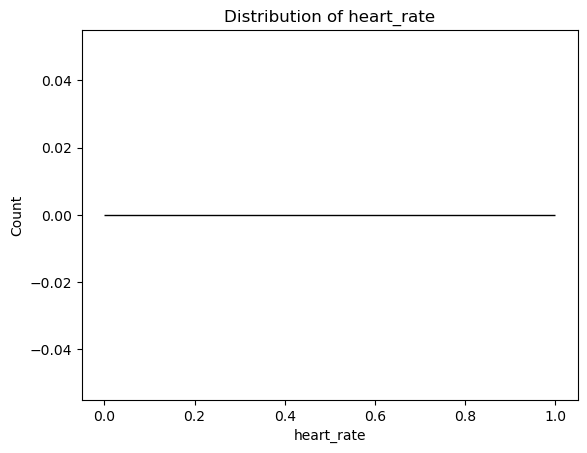

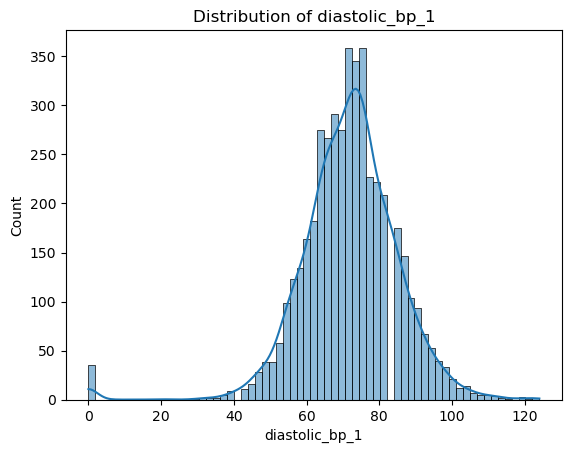

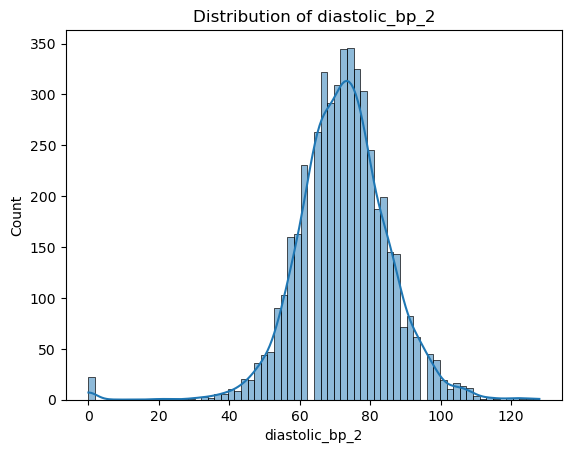

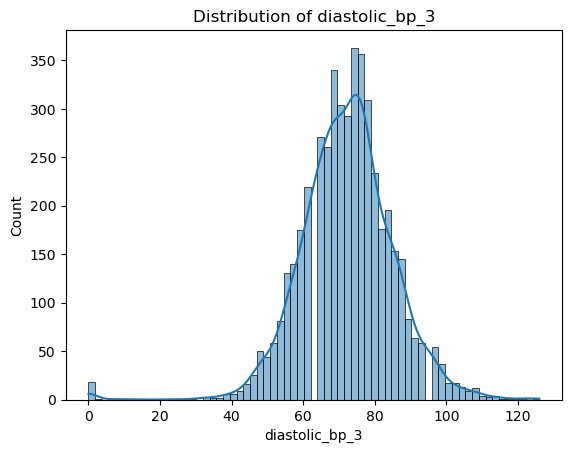

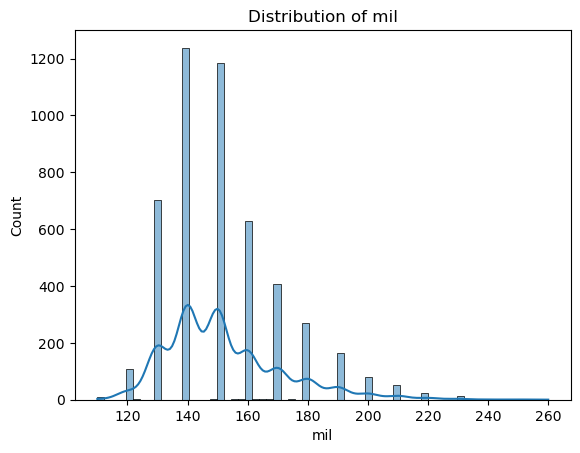

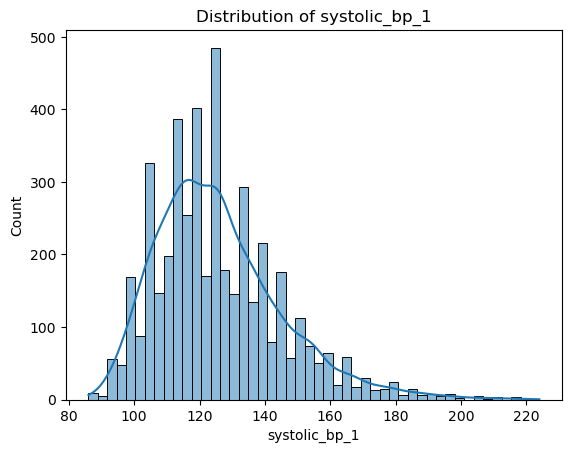

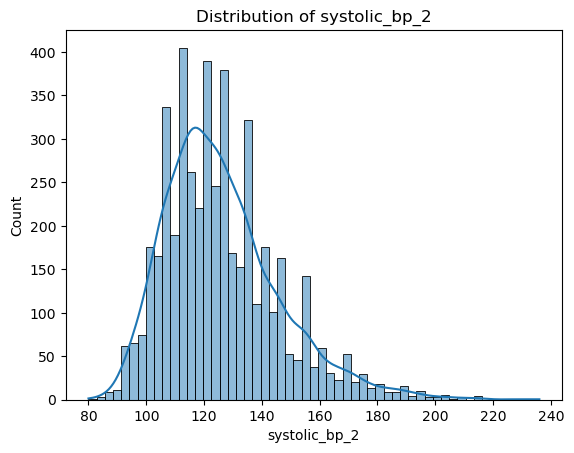

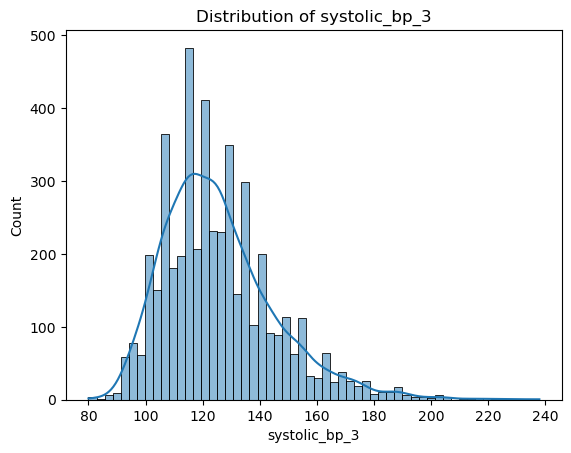

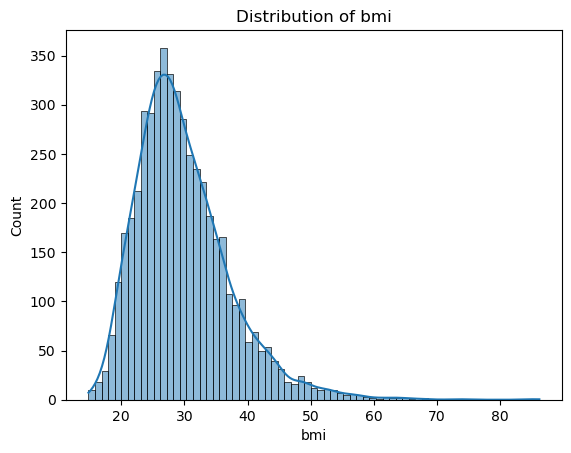

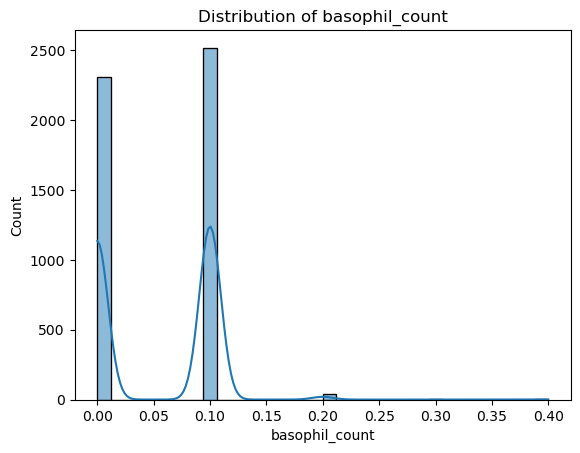

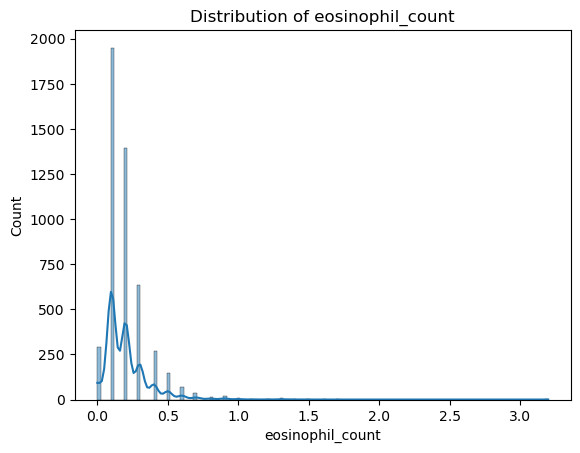

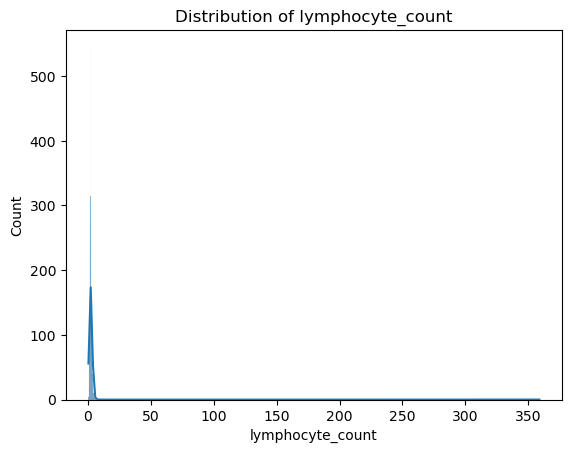

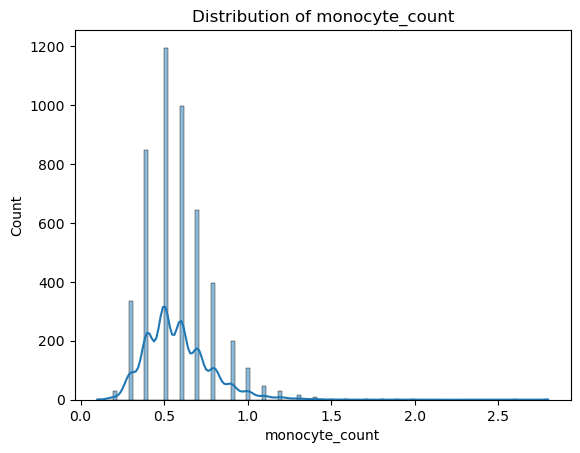

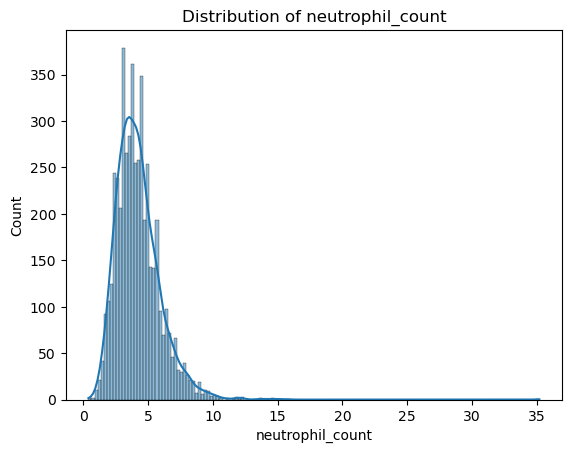

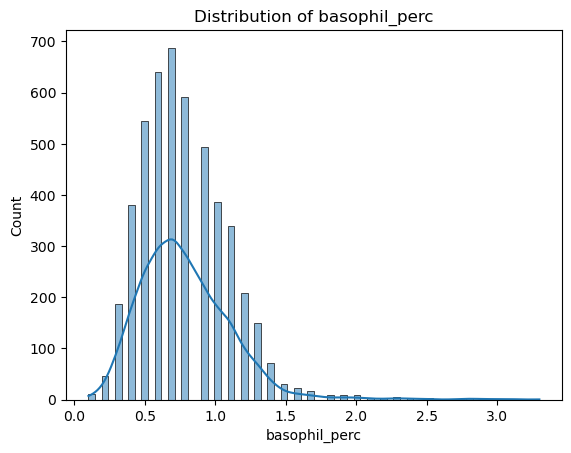

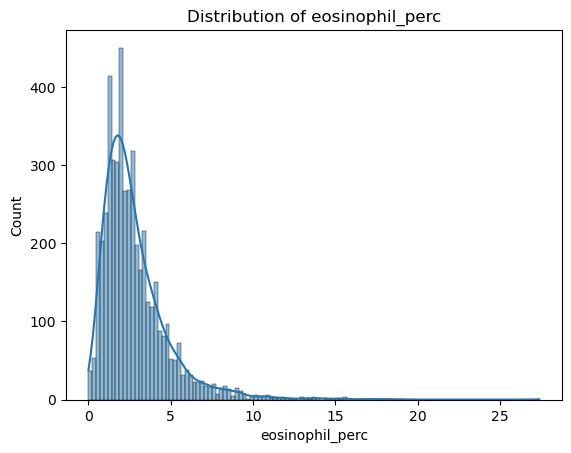

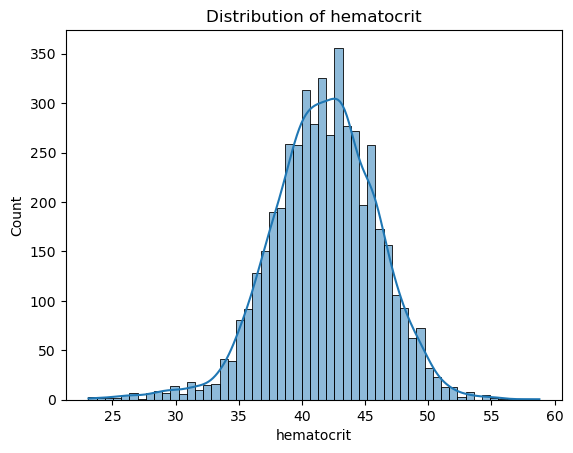

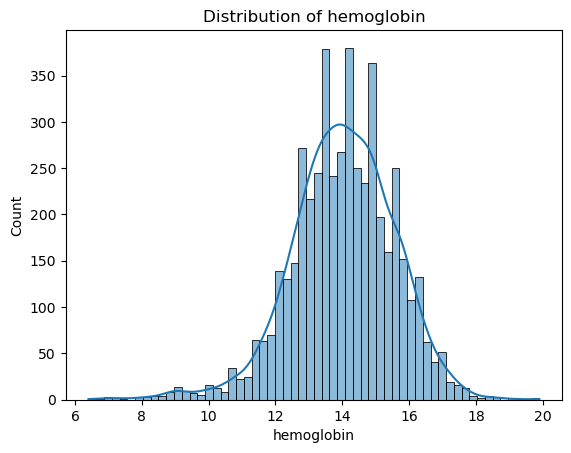

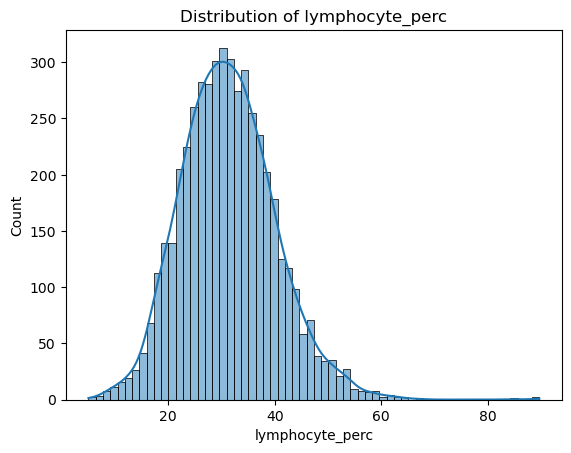

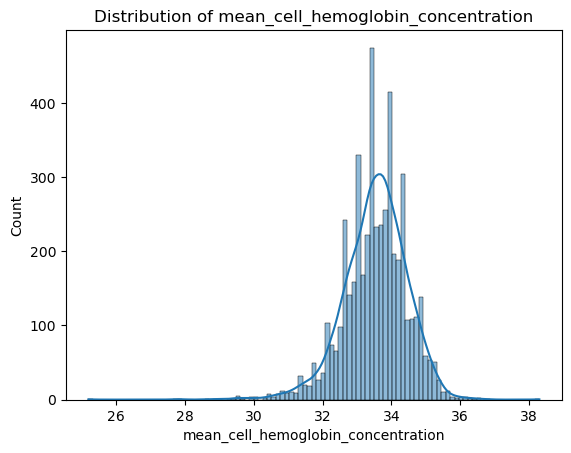

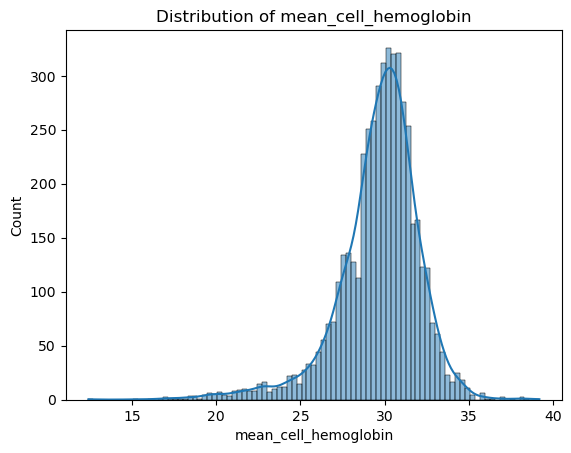

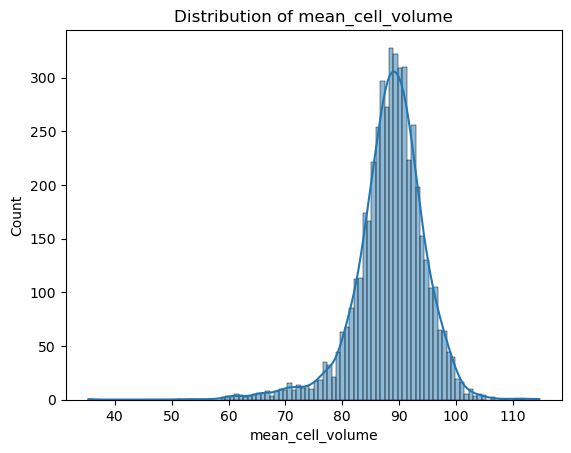

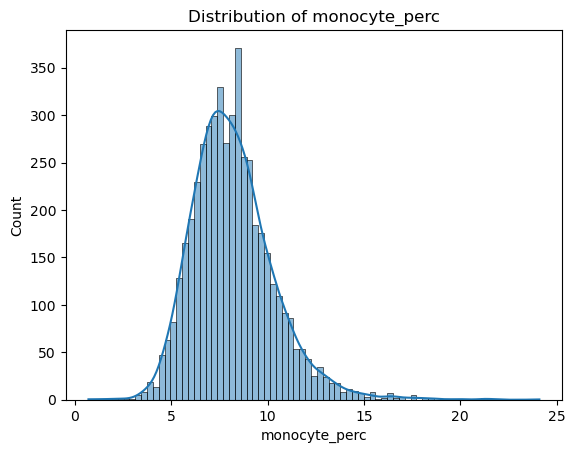

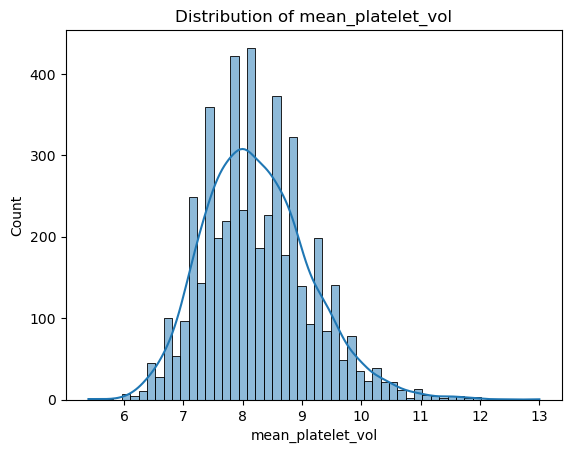

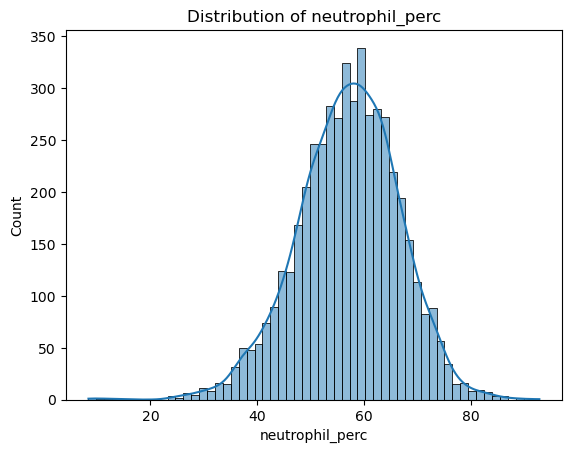

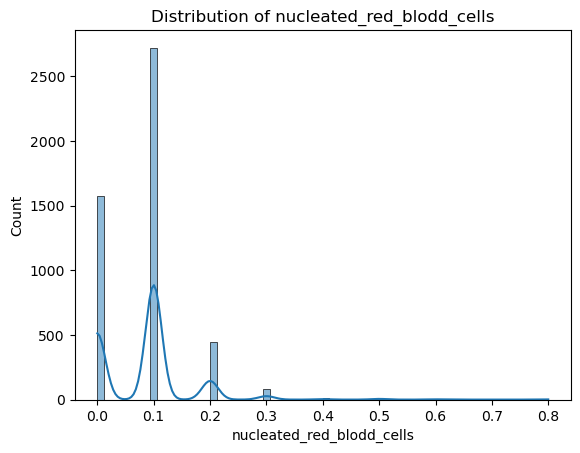

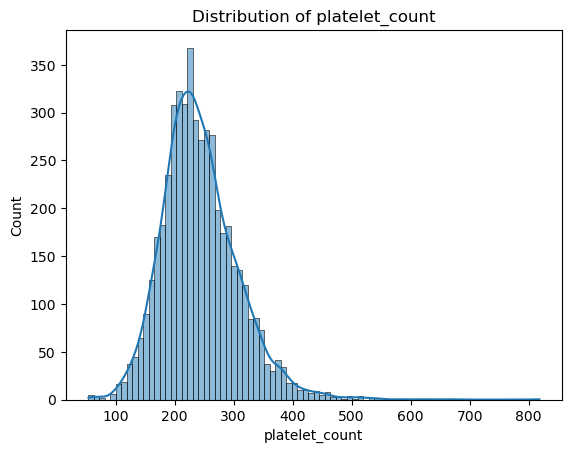

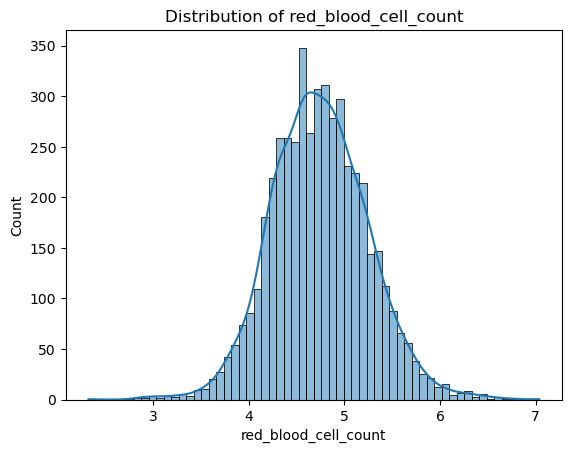

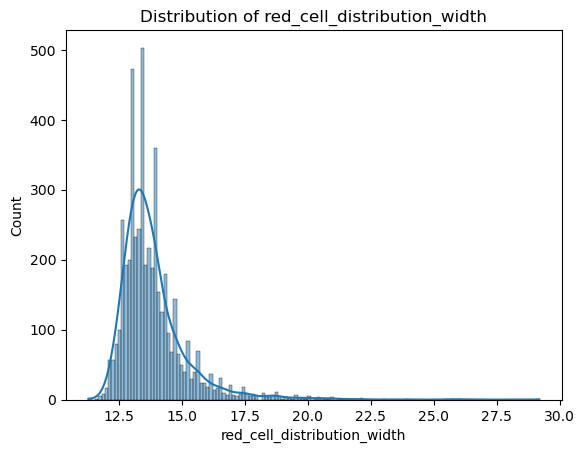

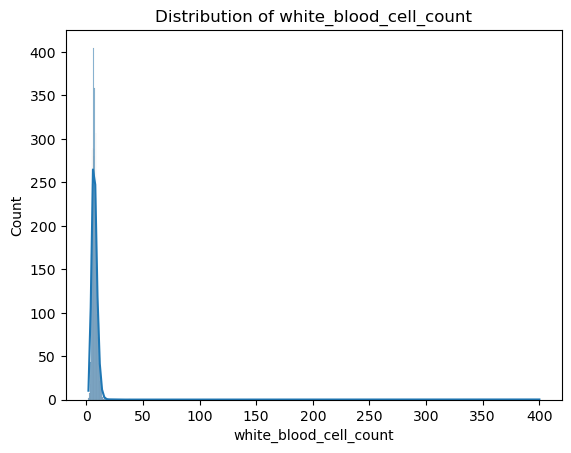

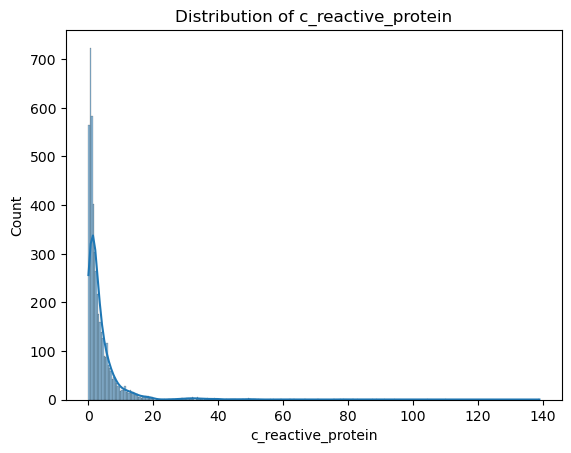

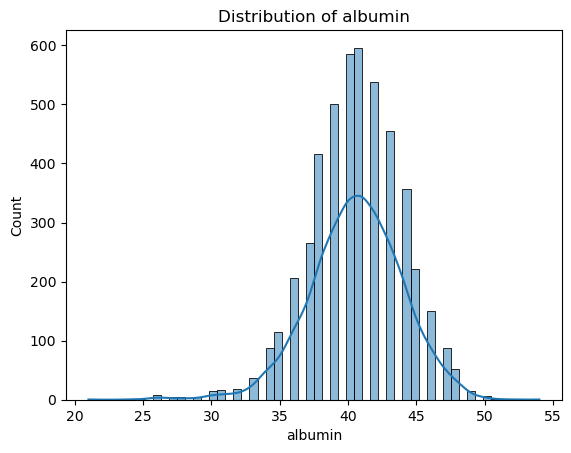

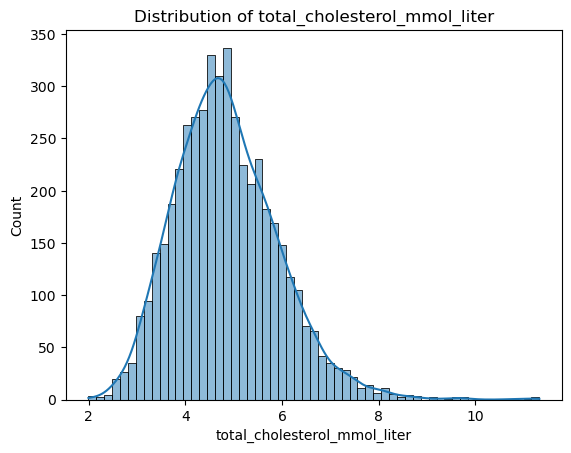

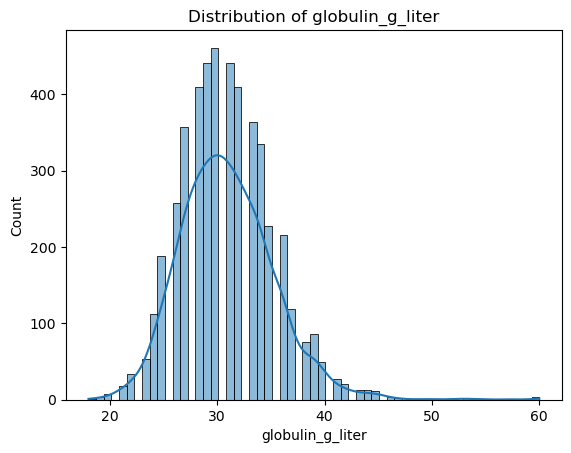

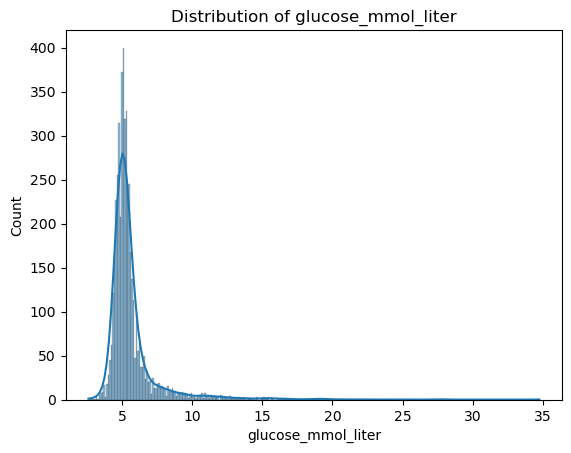

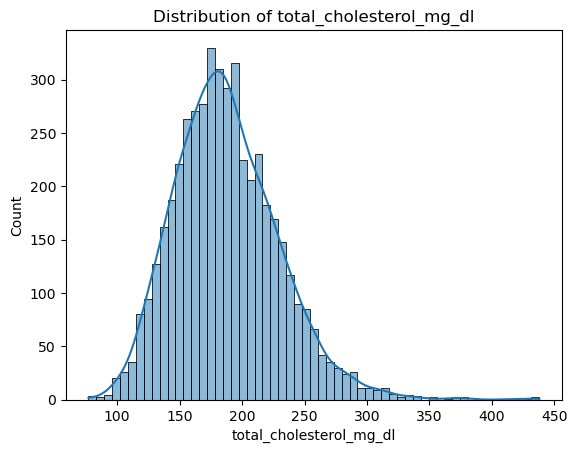

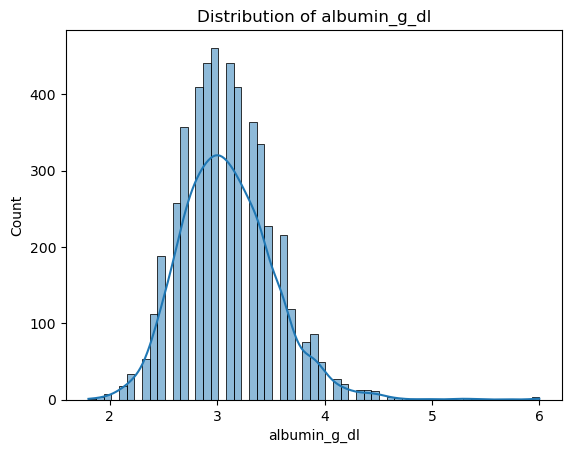

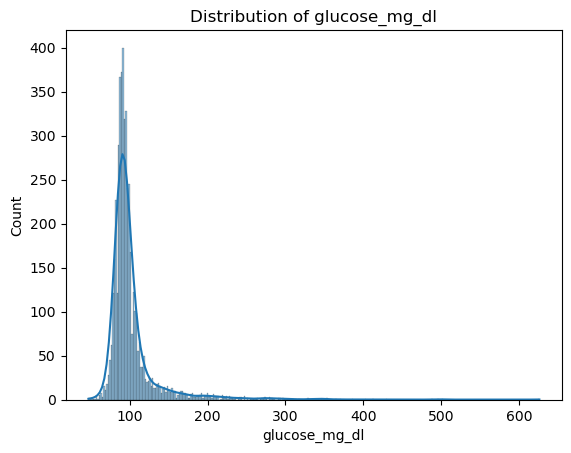

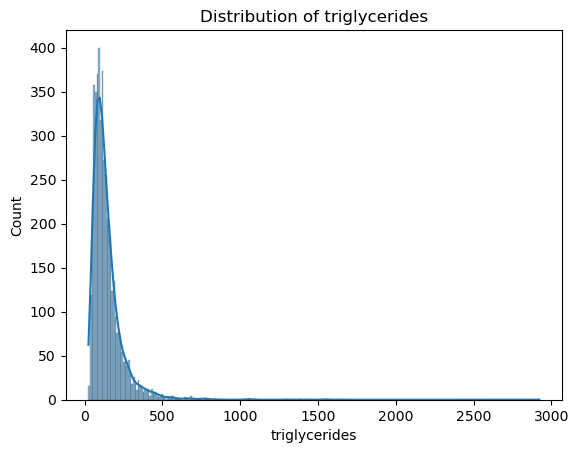

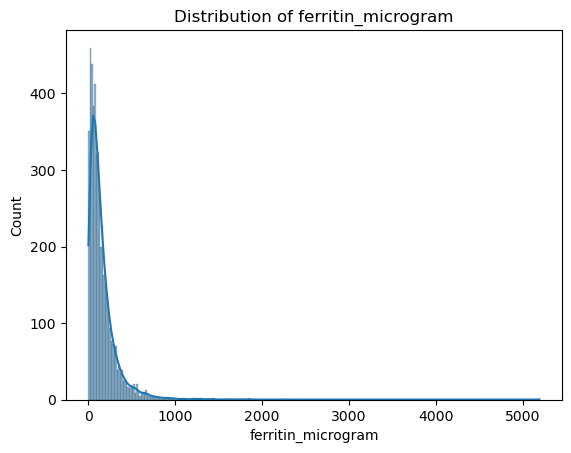

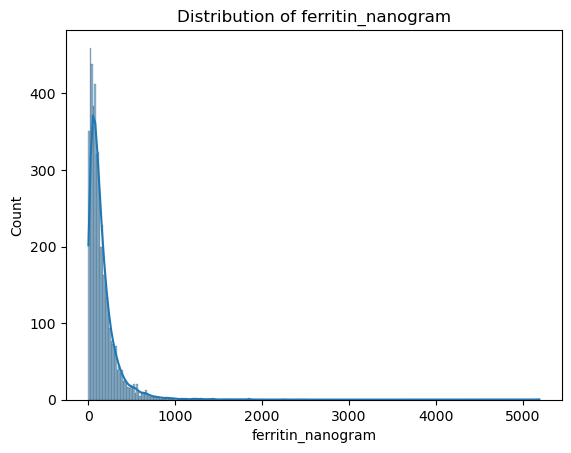

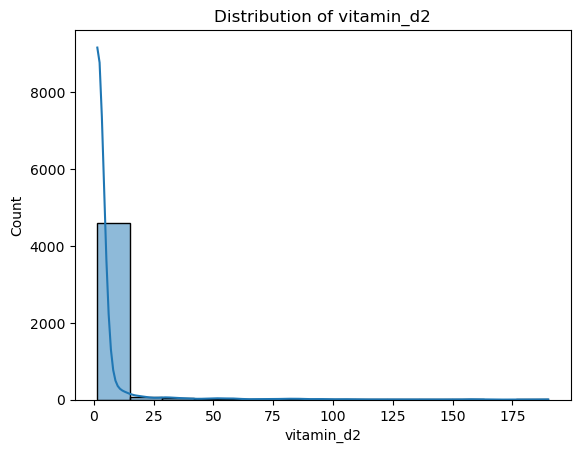

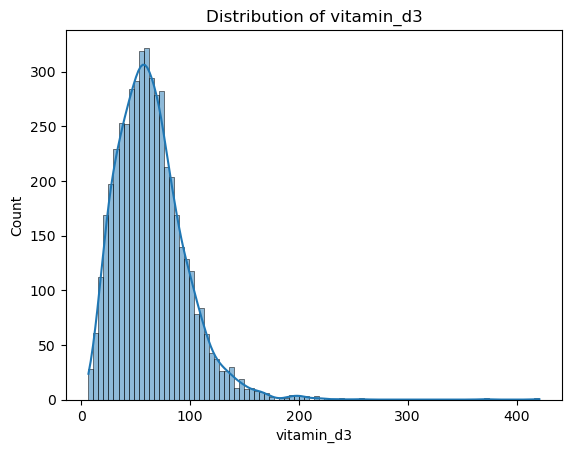

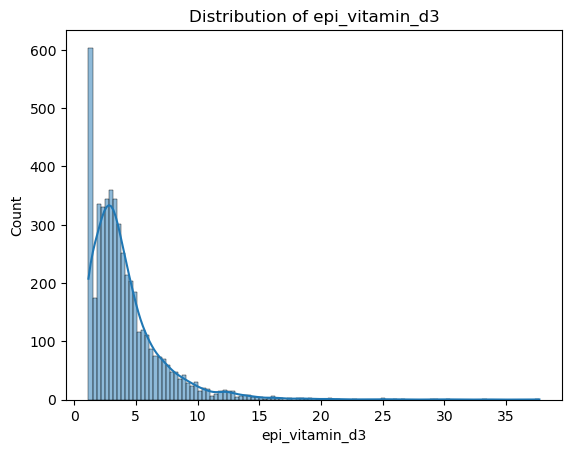

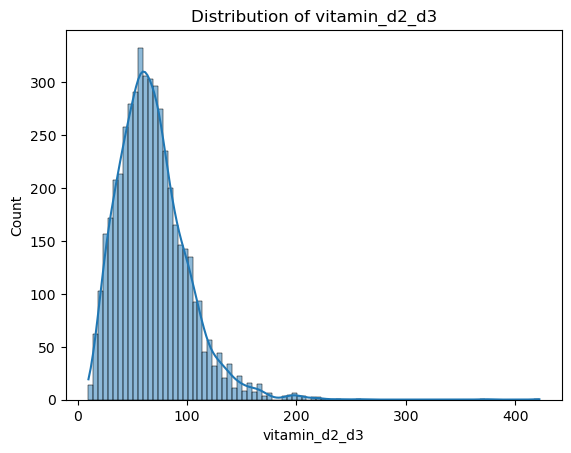

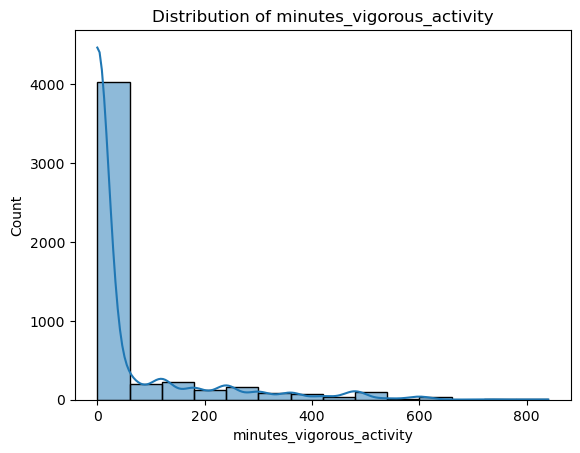

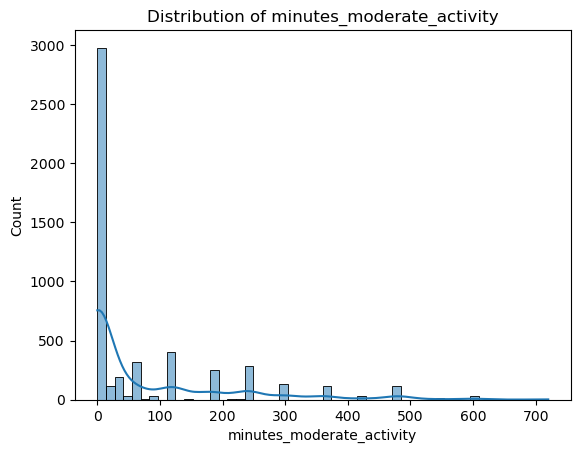

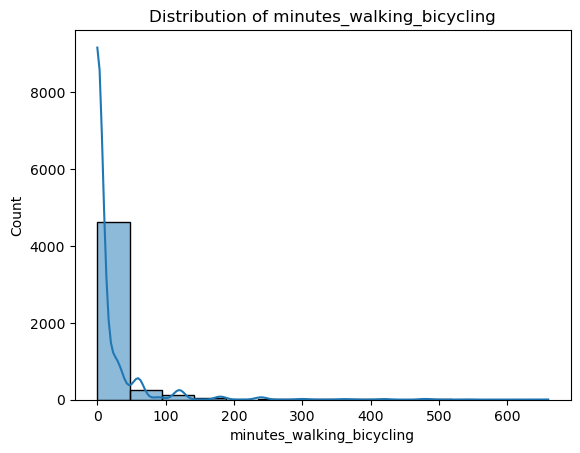

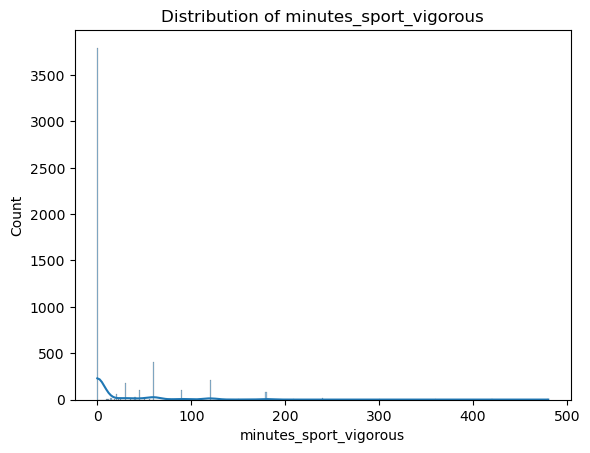

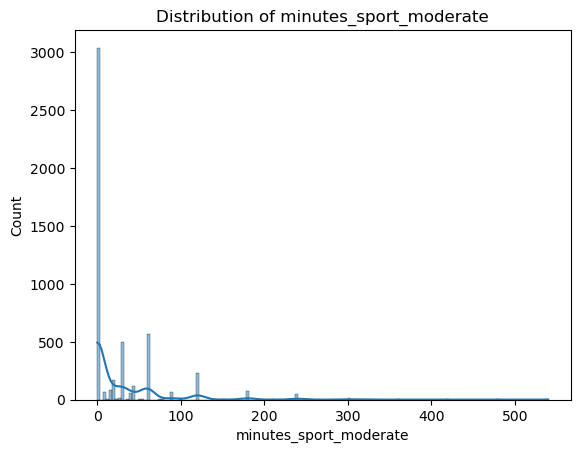

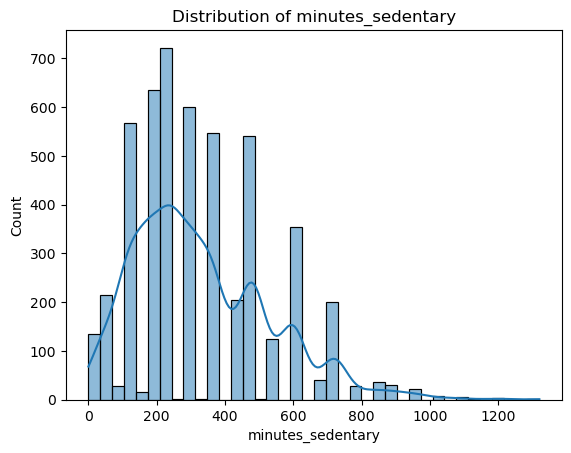

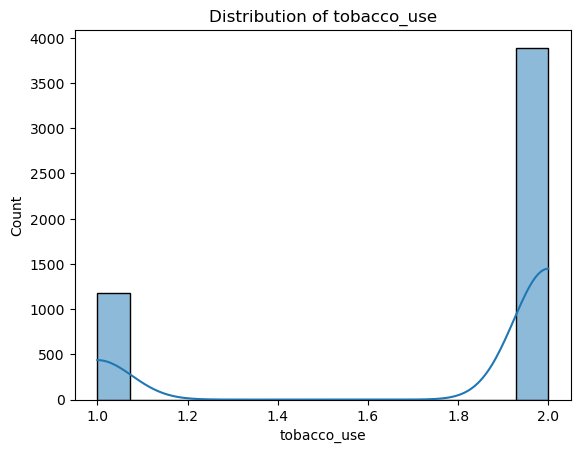

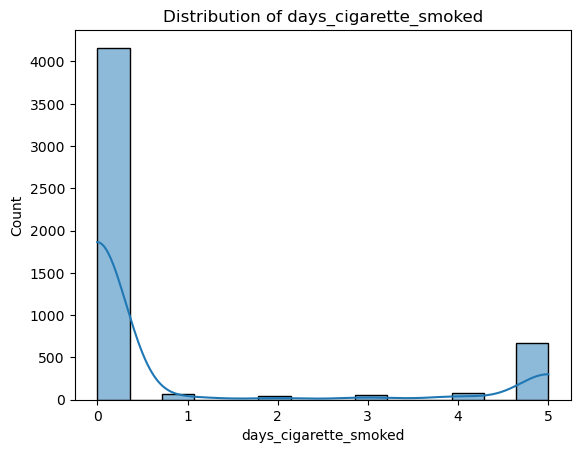

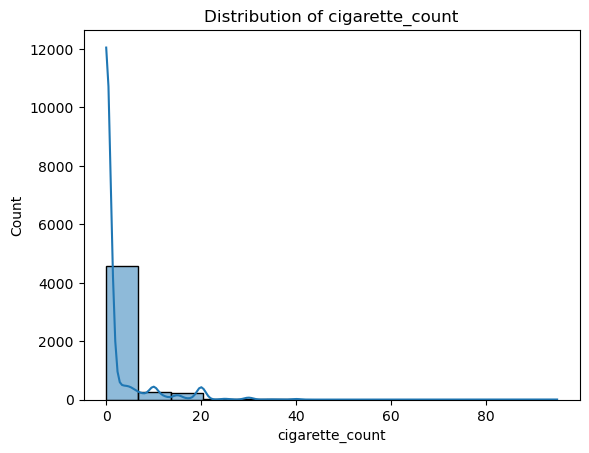

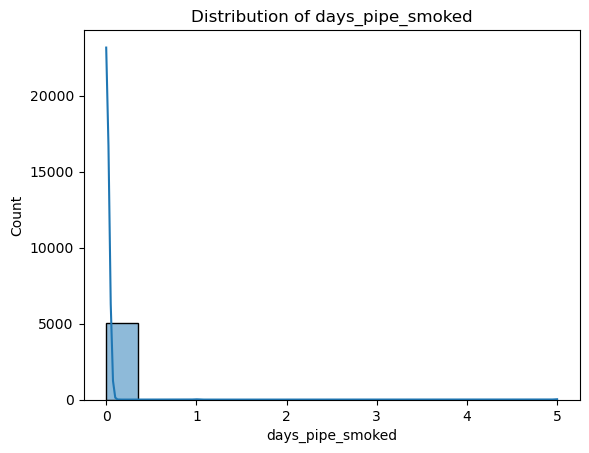

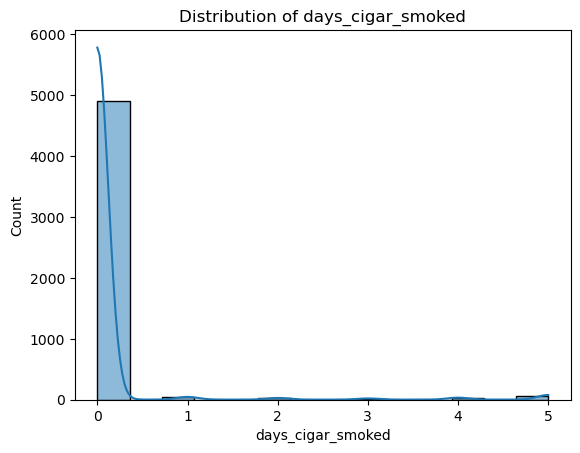

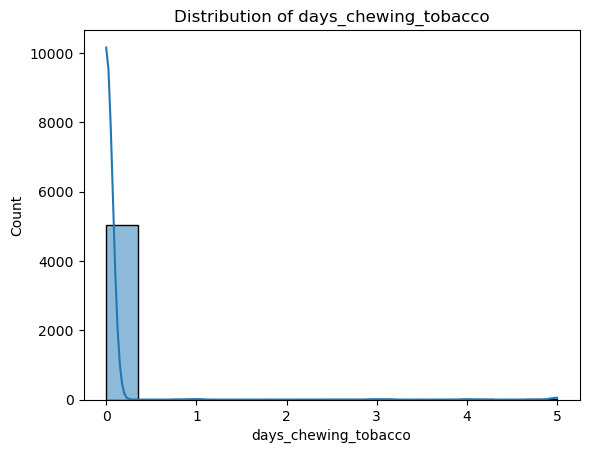

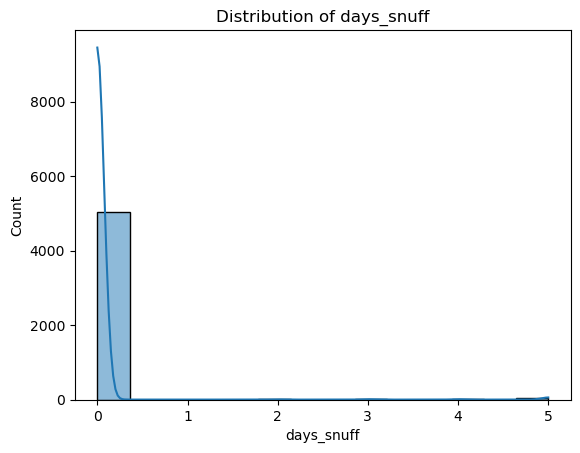

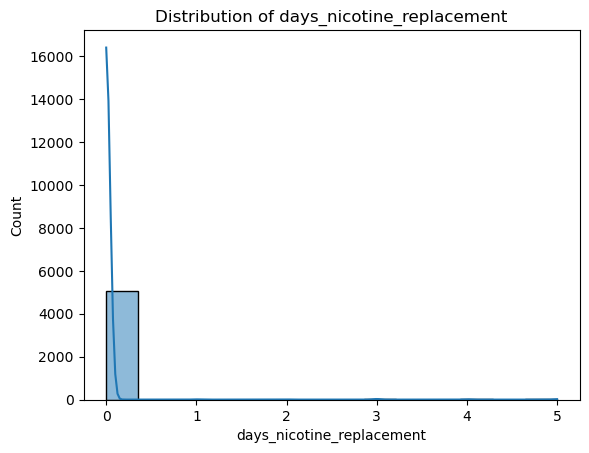

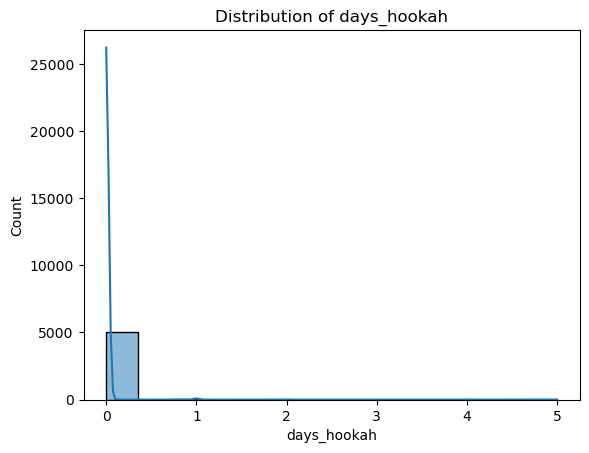

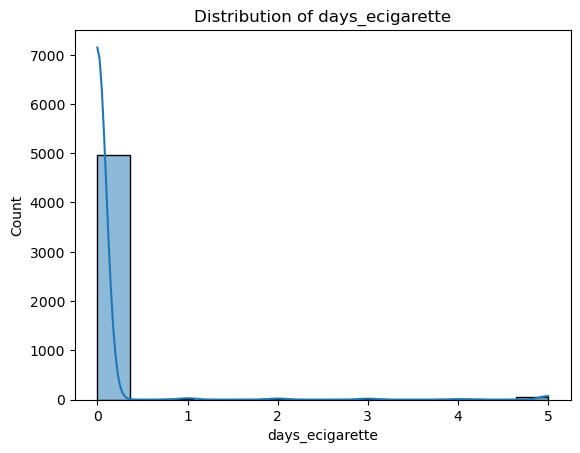

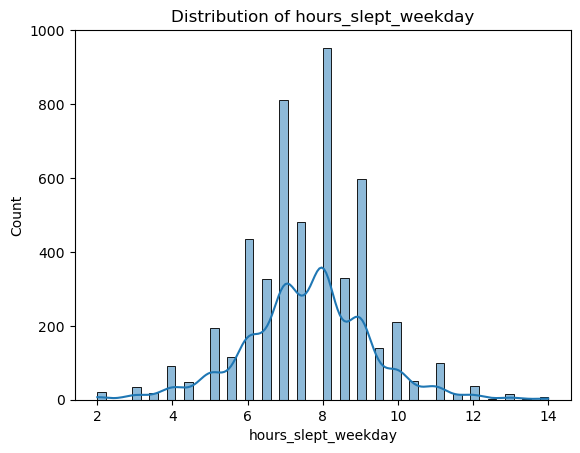

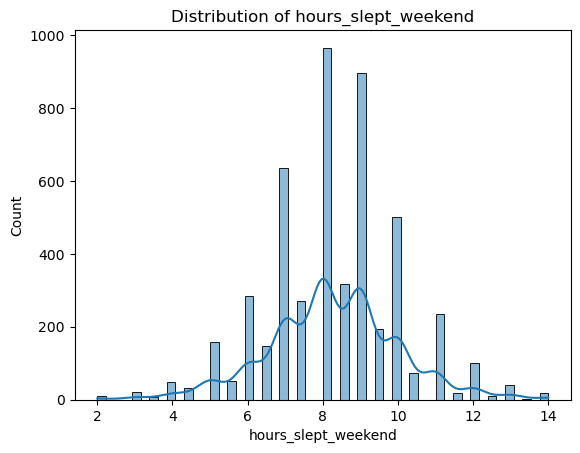

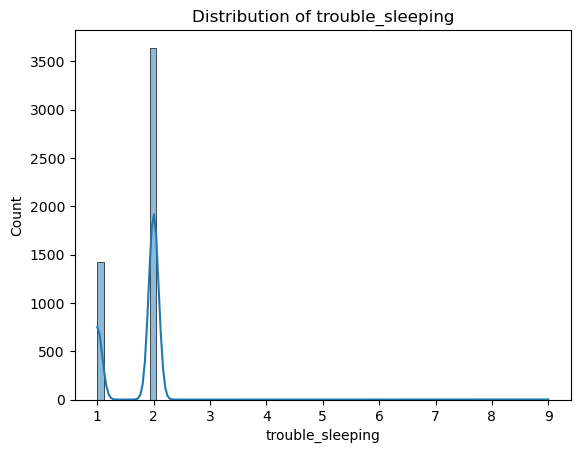

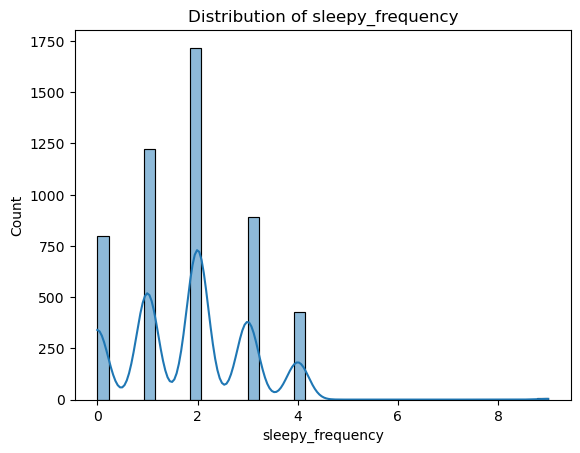

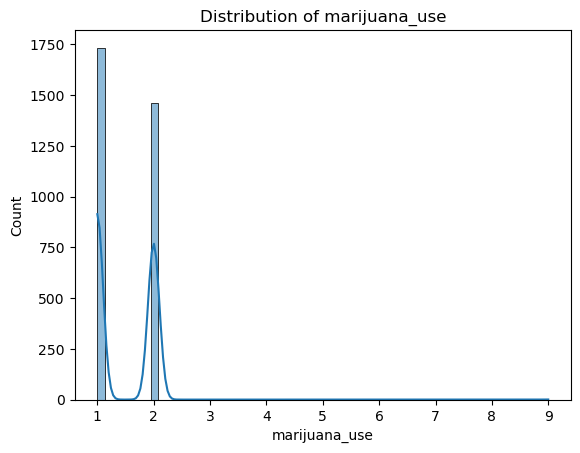

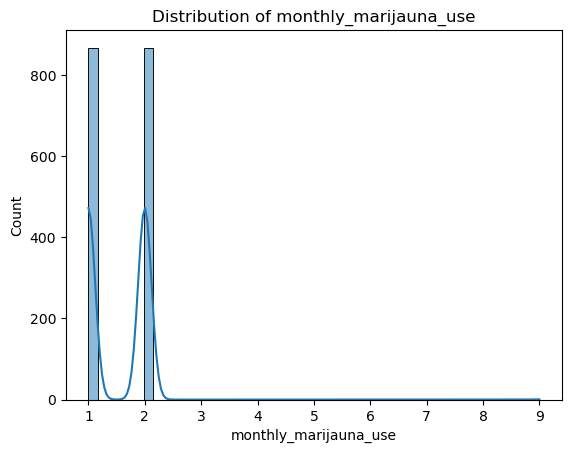

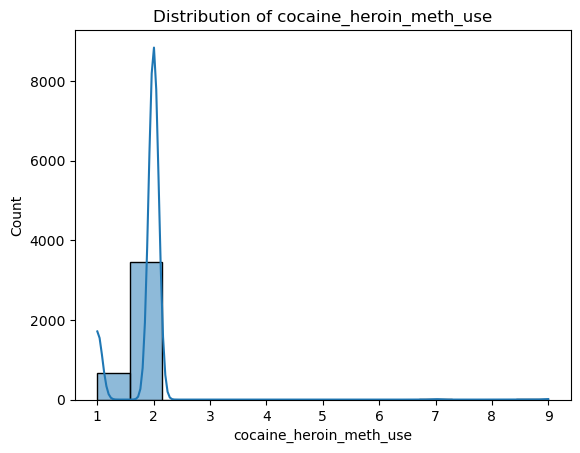

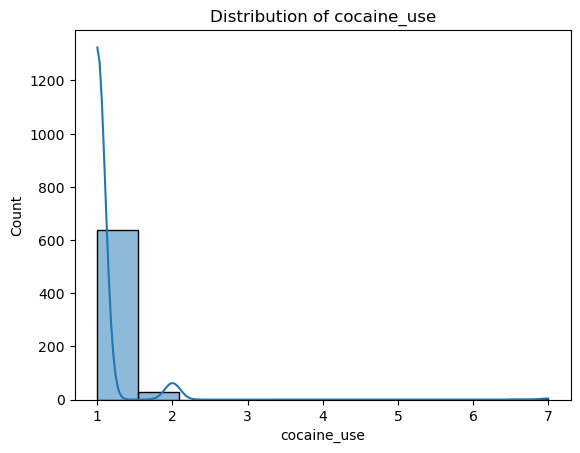

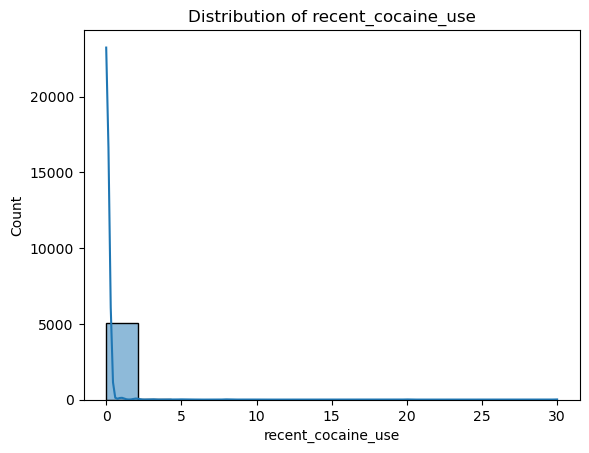

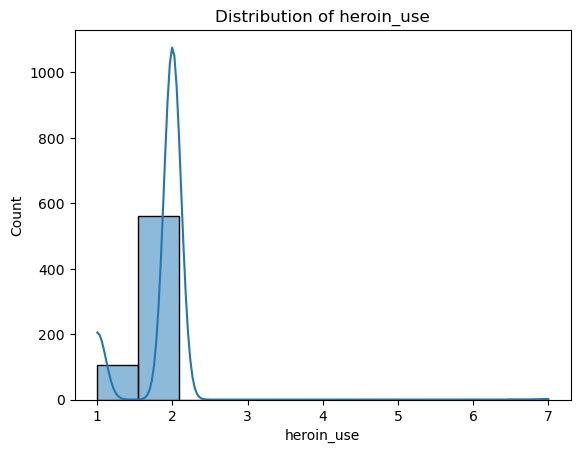

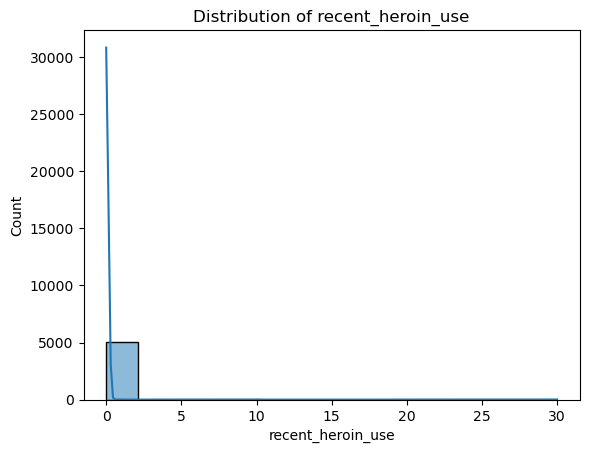

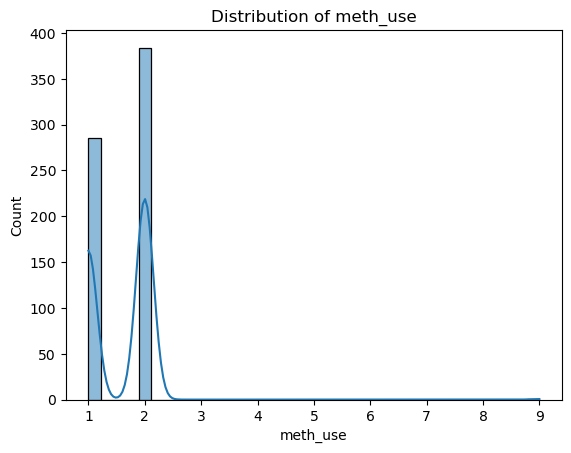

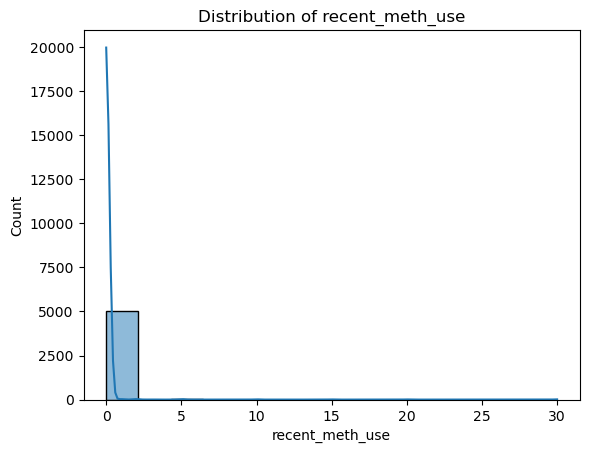

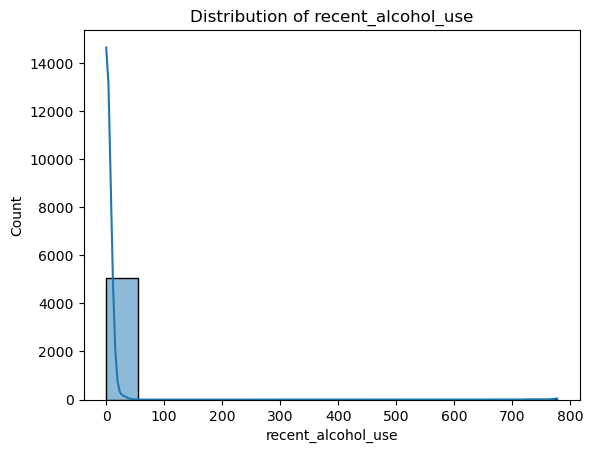

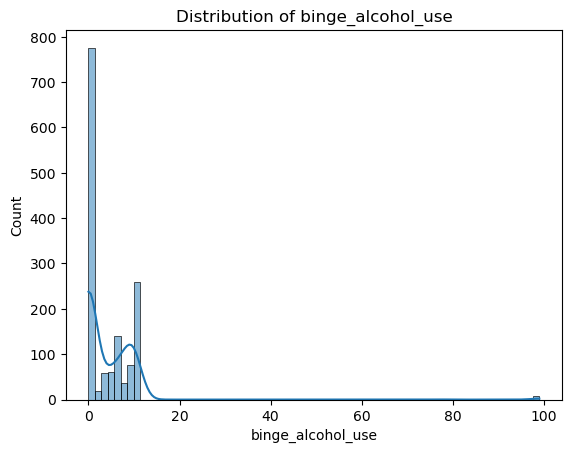

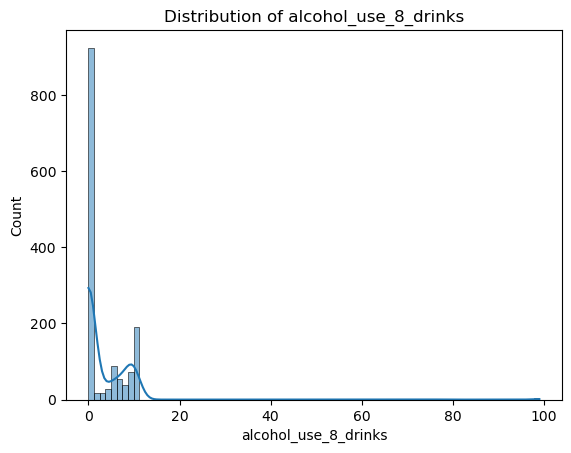

In [5]:
X = df.iloc[:, 1:84]
Y = df.iloc[:, -2:]

for col in X:
    plt.figure()
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

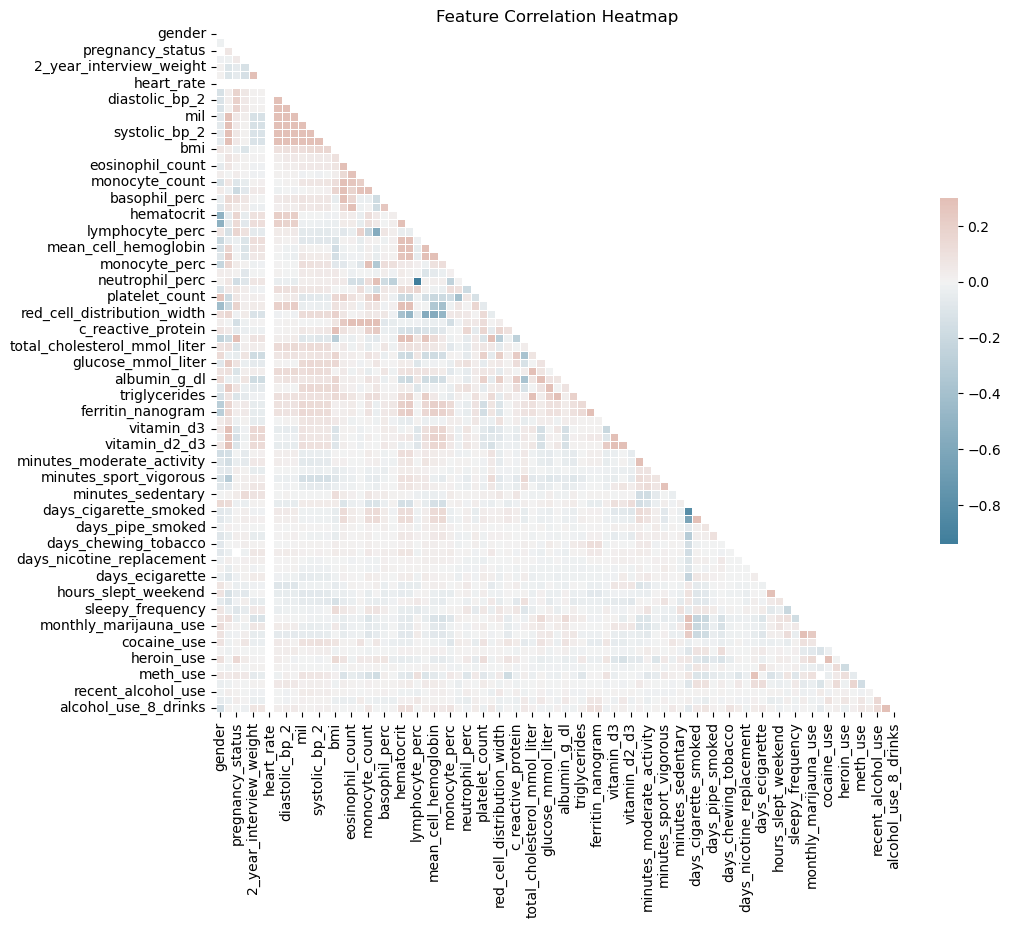

In [6]:
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Feature Correlation Heatmap')
plt.show()